# <center>**Enhancing LEM-X Imaging with the IROS Reconstruction Pipeline**<center>

In [ ]:
from pathlib import Path

from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.io import simulation_files
import darksun as ds

ds.show.set_figures_darkbkg()

In [1]:
# BASE_PATH: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data"
# SIM_PATH: str = f"{BASE_PATH}/Simulations"
# OUT_PATH: str = f"{BASE_PATH}/Outputs"

BASE_PATH: str = "/mnt/d/PhD_AASS/Coding/Images_fits"
SIM_PATH = OUT_PATH = BASE_PATH

In [ ]:
# MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"
UPS_X: int = 2
UPS_Y: int = 1

wfm: CodedMaskCamera = codedmask(f"{SIM_PATH}/{MASK_FITS}", UPS_X, UPS_Y)

In [ ]:
SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"
# SKYFIELD: str = "GalacticCentre"
# DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

RUN_ID: str = 'test_routine_2-6keV'

filepaths: dict[str, dict[str, Path]] = simulation_files(f"{SIM_PATH}/{SKYFIELD}/{DATA_FITS}")

E_min, E_max = 2.0, 6.0   # [keV]

sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET], E_min=E_min, E_max=E_max)
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET], E_min=E_min, E_max=E_max)

**Analysis prompt**

 * **Sky Reconstruction Efficiency:**
     - true-IROS slices
     - fitted sources params (residues WRT true)
     - CFR between true and IROS sky images
 
 * **Spectroscopic Capabilities**
     - ScoX-1 spectrum reconstruction (or at least the interesting part for state change)
 
 * **BKG Smoothing**

<br>

**Discussions prompt**

 * **Inter-px grid resolution:**
    - sources parameters estimation
    - procedure computational cost
    - CFR with instr./on-fly errors

 * **Double-Camera Enhancement:**
    - improved localisation with Unit fine dirs
    - CFR with GW170817 sky uncertainty box of $~31 \text{deg}^{2}$ at 90% prob --during measurements-- (transient obs alarm and sky area uncertainty)
 
 * **Energy bands impact and limitations**
    - instrumental effects modelling
    - source template modelling
    - source optimisation routine
    - **NOTE:** these are content for a second analytic IROS paper (**analyses and tests already done!**)
        * multi-energy bands IROS reconstruction
        * source template with ebands components
        * energy-dependent instr. effects modelling (supported by mock sources tests)

<br>

<br>

<br>

### **Sky Reconstruction Efficiency**

In [ ]:
from bloodmoon.mask import count, decode

detector, _ = count(wfm, sdlA.DLdata)
true_skyA = decode(wfm, detector)
logA, _ = ds.load_database(f"{SIM_PATH}/{RUN_ID}/IROS_sources_database.fits")

# Loading data...
# Loading completed!


In [10]:
from typing import Any
import numpy as np
from numpy.typing import NDArray

def custom_slices_plot(
    camera: CodedMaskCamera,
    sky: NDArray | tuple[NDArray],
    pos: tuple[int, int],
    crp: tuple[int, int],
    *,
    title_prefix: str | None = None,
    ylabel: str | None = None,
    ylim_xslice: tuple[Any, Any] | None = None,
    ylim_yslice: tuple[Any, Any] | None = None,
    labels: str | tuple[str | None] | None = None,
    color: str | tuple[str] | None = None,
    save_to: str | Path | None = None,
    **kwargs: Any,
) -> None:
    """
    Plots horizontal and vertical slices of 2D data arrays centered at a given position.
    """
    def phase(x: NDArray) -> NDArray:
        """Centers x-axis values around zero."""
        return np.arange(len(x) + 1) - len(x) // 2 - 0.5
    
    cropped = tuple(
        ds.crop(s, pos, crp, strict=False) for s in (
            (sky,) if isinstance(sky, np.ndarray) else sky
        )
    )
    xslice, yslice = zip(
        *tuple((c[crp[0], :], c[:, crp[1]]) for c in cropped)
    )
    title_prefix_ = f'{title_prefix} | ' if title_prefix is not None else ''
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    kws = {
        'ylabel': ylabel or 'counts [ph]',
        'labels': labels,
        'style': 'stairs',
        'color': color,
    }
    dmapx = ds.map4plot(
        arrs=xslice,
        title=f"{title_prefix_}" + "X-axis Slice",
        xlabel='$\\theta_{fine}$ [arcmin]',
        x=map(lambda x: dtx * phase(x), xslice),
        ylim=ylim_xslice or (None, None),
        **kws,
    )
    dmapy = ds.map4plot(
        arrs=yslice,
        title=f"{title_prefix_}" + "Y-axis Slice",
        xlabel='$\\theta_{coarse}$ [deg]',
        x=map(lambda y: dty * phase(y) / 60, yslice),
        ylim=ylim_yslice or (None, None),
        **kws,
    )
    ds.plot(
        dmaps=(dmapx, dmapy),
        ncols=2,
        save_to=save_to,
        **kwargs,
    )
    return

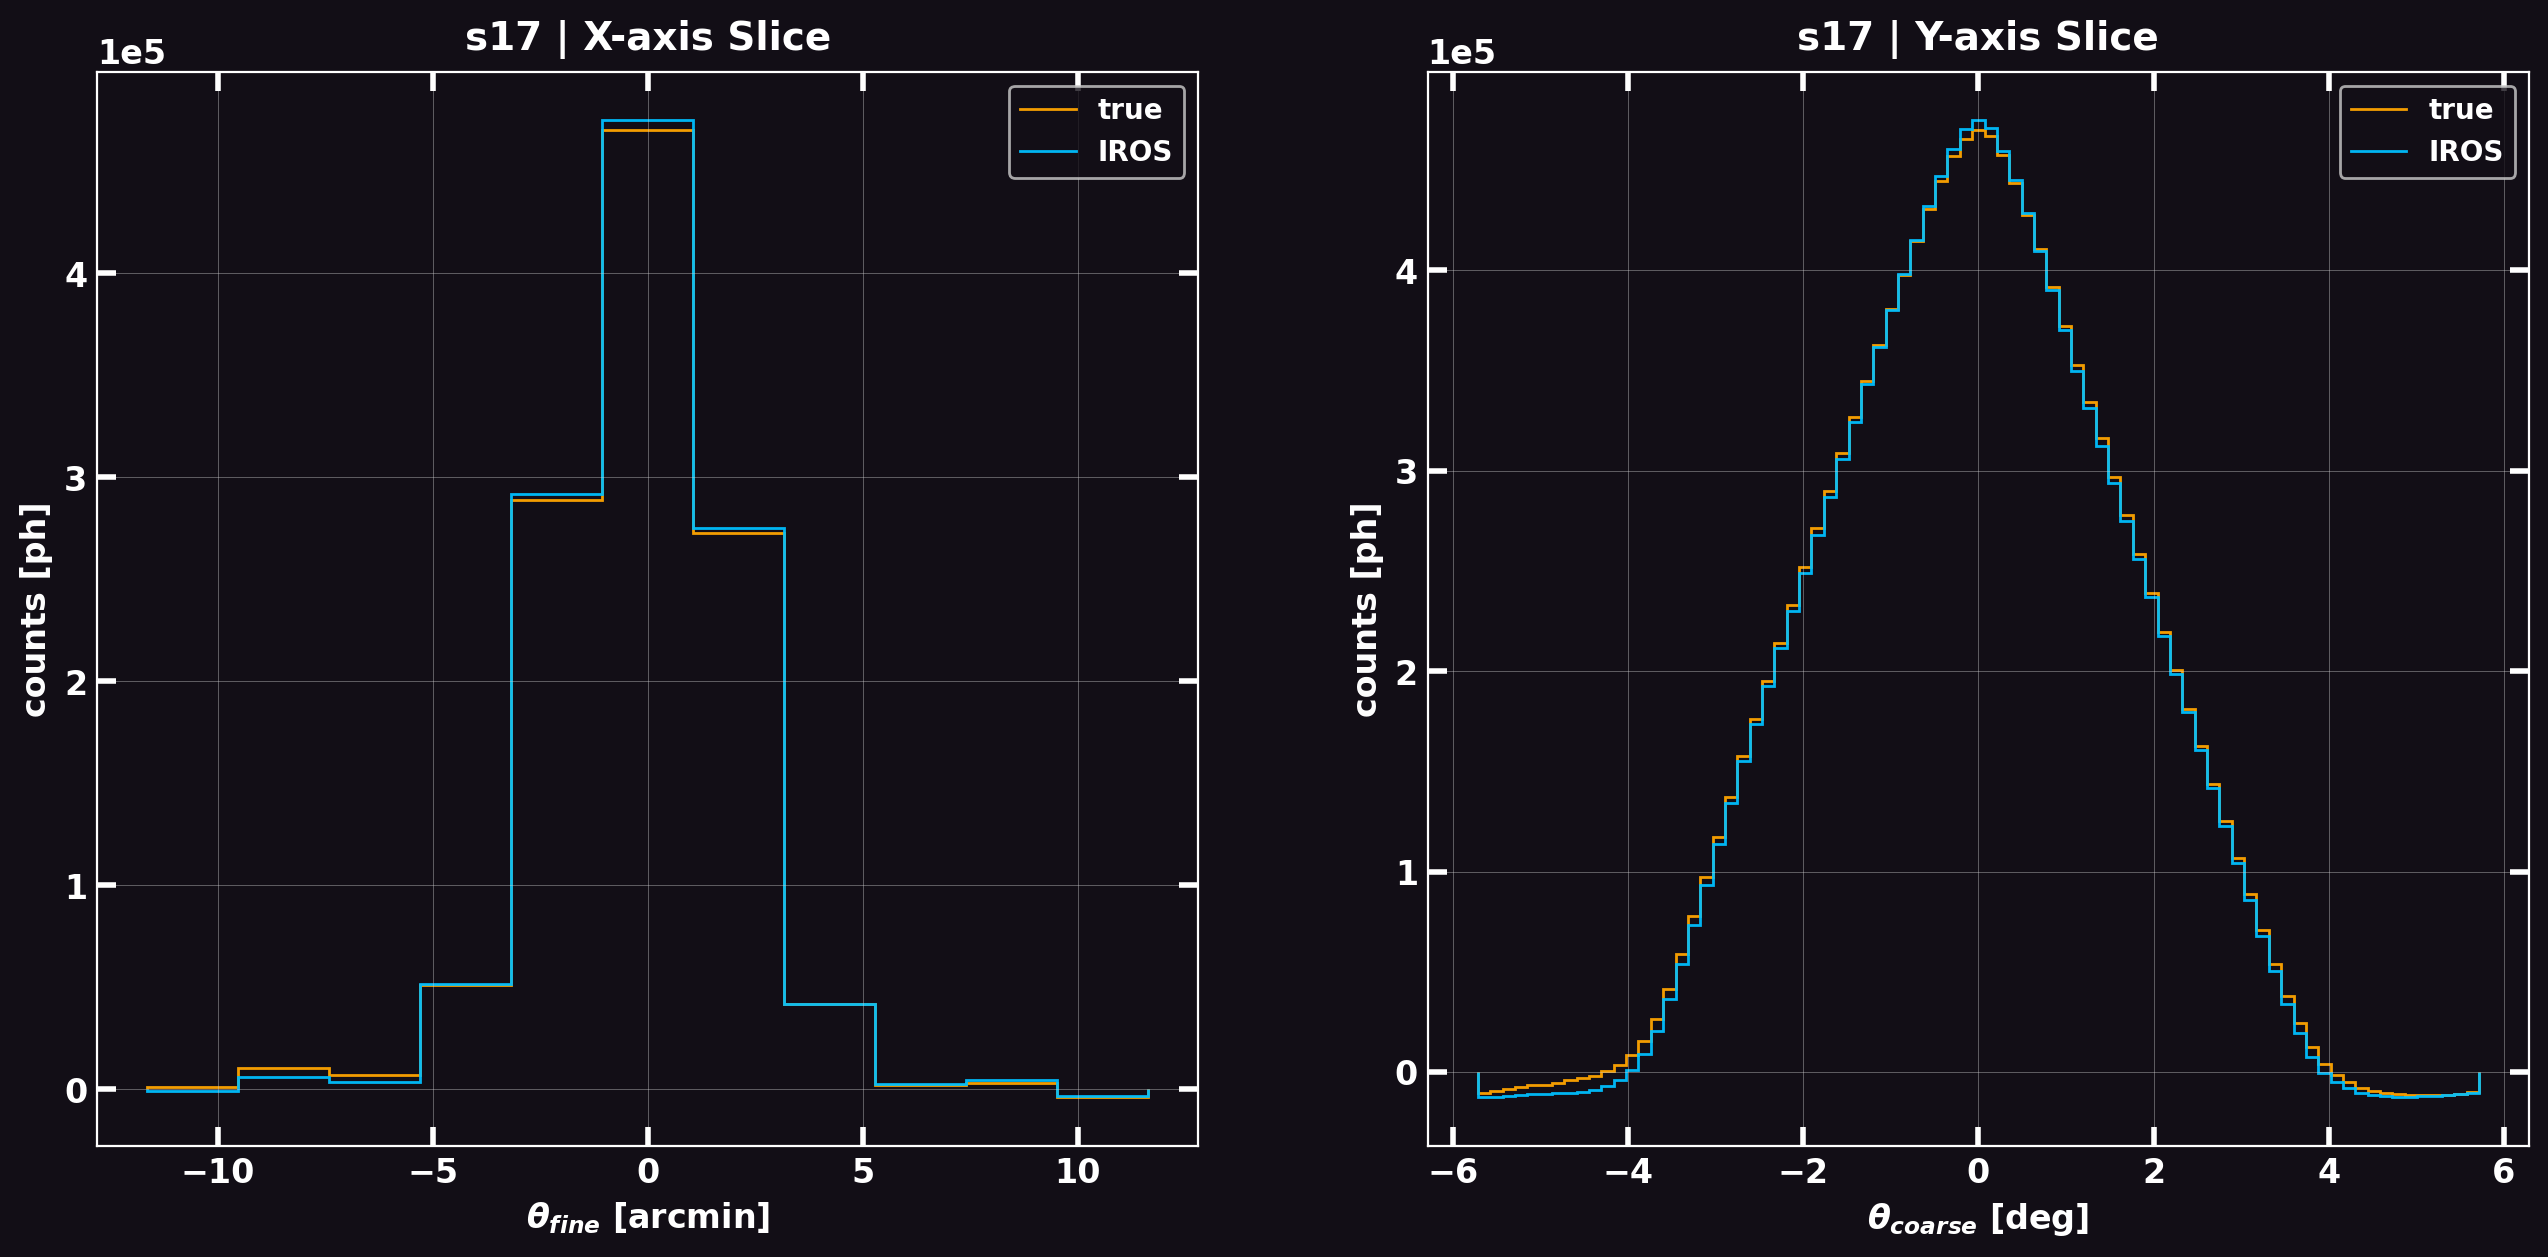

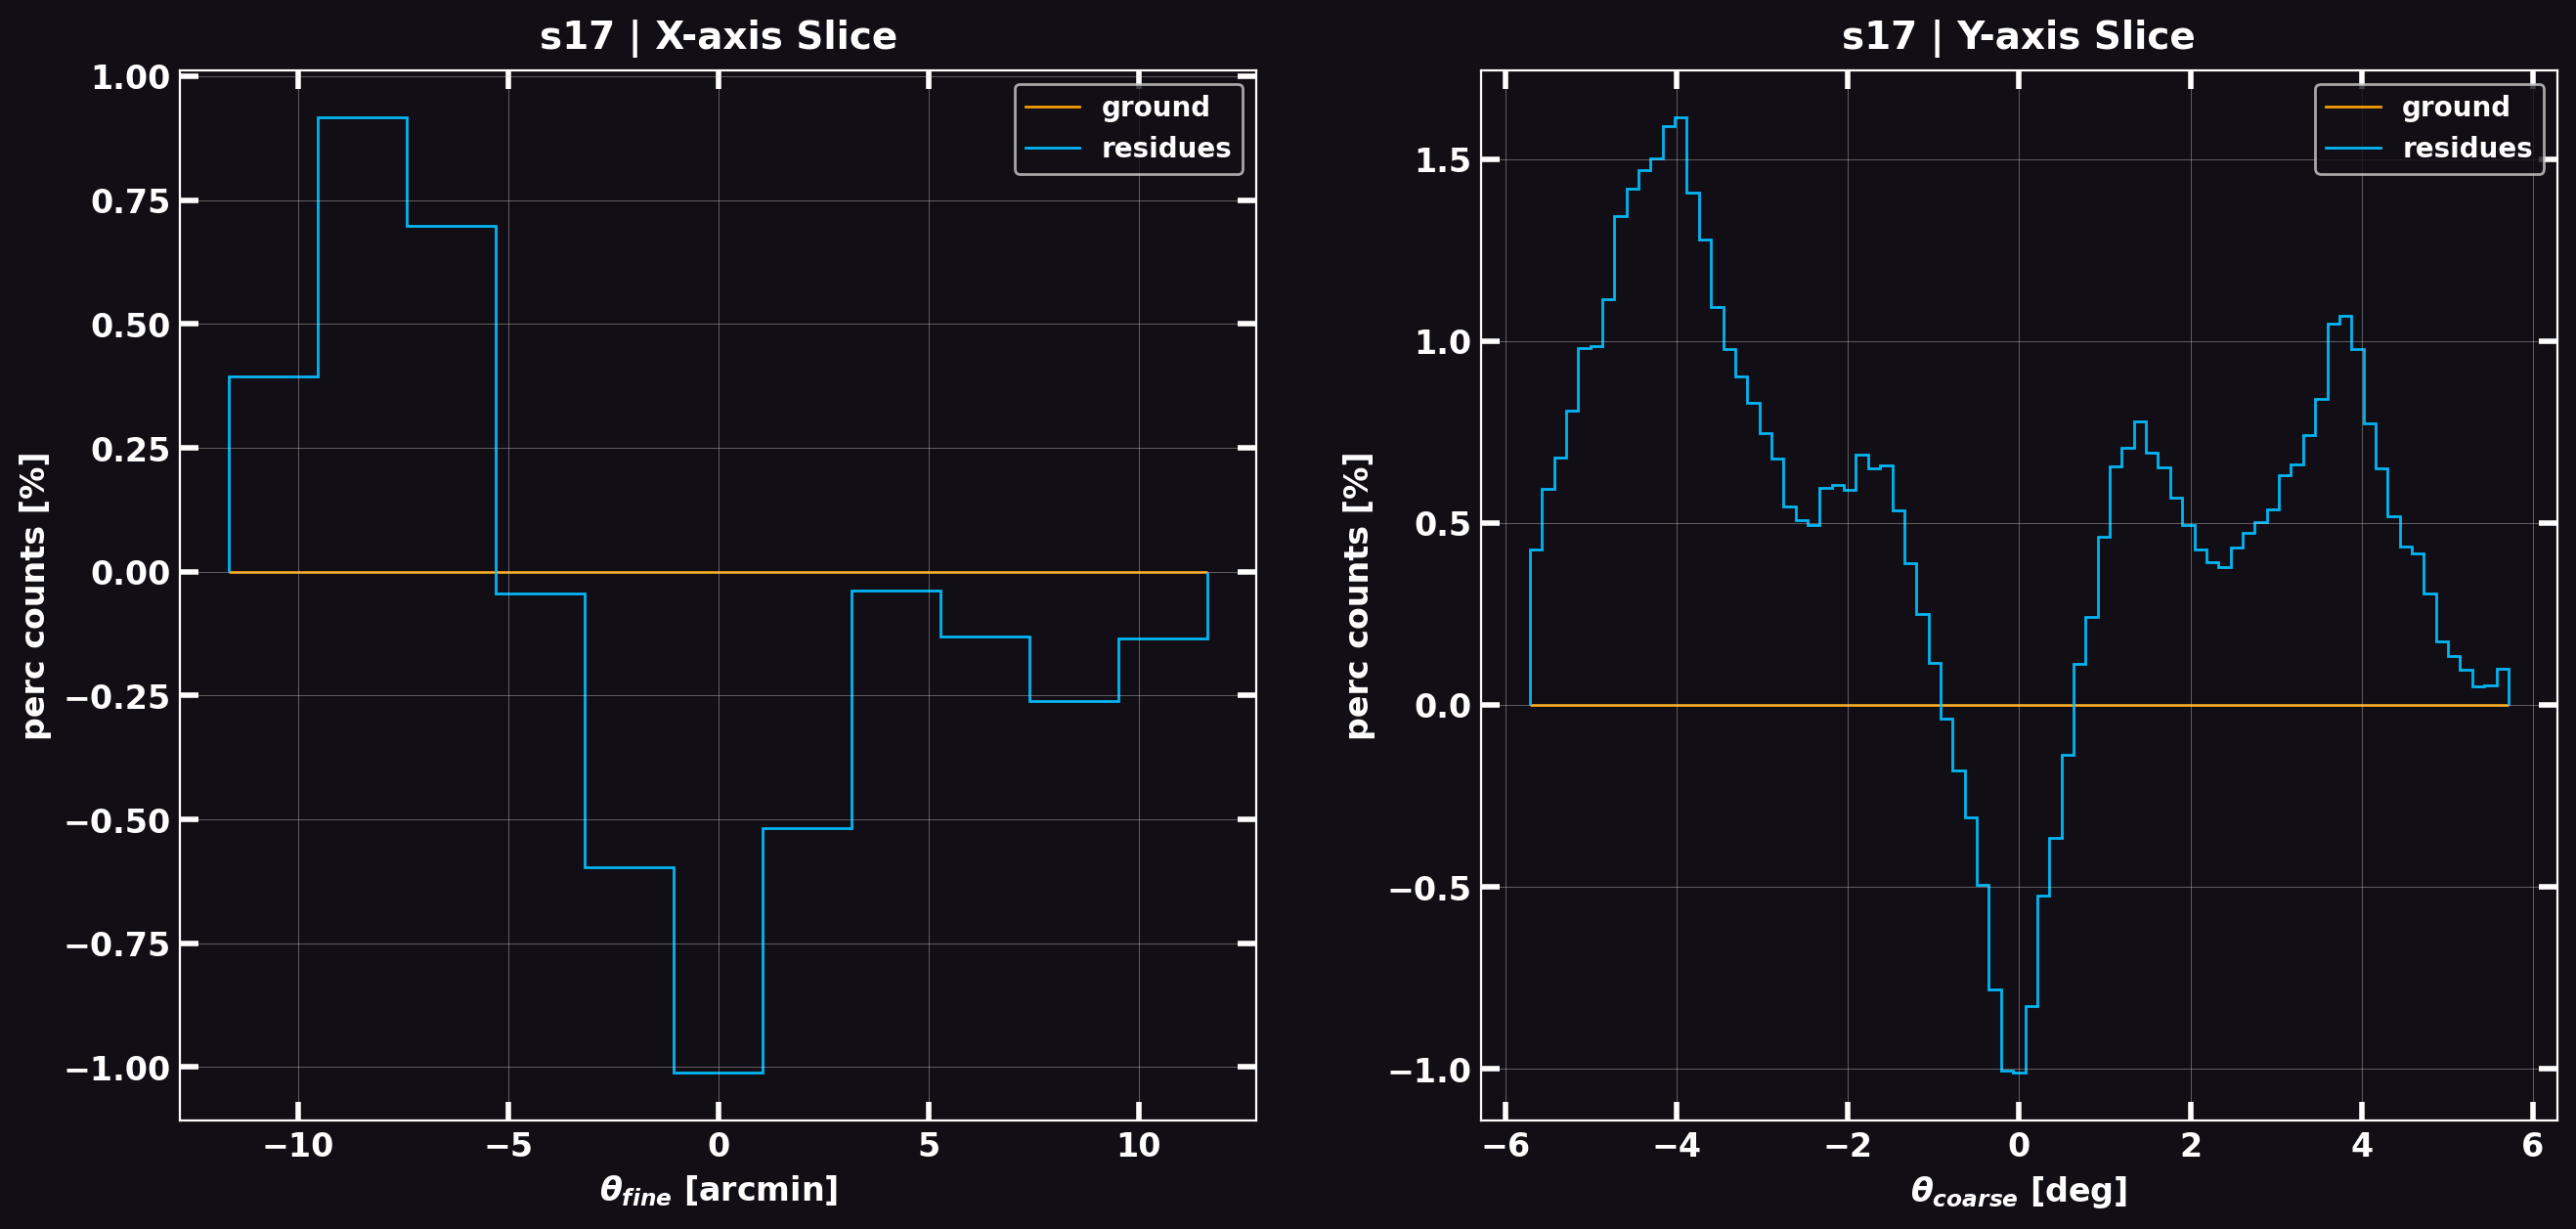

In [11]:
from bloodmoon.optim import model_sky

IDX: int = 0
KWS = {
    'pos': (logA.log['y'][IDX], logA.log['x'][IDX]),
    'crp': (40, 5),
    'title_prefix': logA.log['ID'][IDX],
    'color': ('Orange', 'DeepSkyBlue'),
}

template = model_sky(wfm, logA.log['shift_x'][IDX], logA.log['shift_y'][IDX], logA.log['fluence'][IDX])
residues = (true_skyA - template) * 100 / true_skyA[KWS['pos']]

custom_slices_plot(
    camera=wfm,
    sky=(true_skyA, template),
    labels=('true', 'IROS'),
    **KWS,
)
custom_slices_plot(
    camera=wfm,
    sky=(np.zeros_like(residues), residues),
    labels=('ground', 'residues'),
    ylabel=r'perc counts [%]',
    **KWS,
)